In [16]:
import pandas as pd
import numpy as np
import joblib
import json
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================

# Load cleaned two-column CSV (project: dataset/ or cwd)
_root = Path.cwd()
_csv = _root / 'dataset' / 'Allergen_Status_of_Food_Products.csv'
if not _csv.exists():
    _csv = _root / 'Allergen_Status_of_Food_Products.csv'
df = pd.read_csv(_csv)

# Clean column names (strip hidden spaces)
df.columns = df.columns.str.strip()

# Process Target (Label Encoding)
# 'contains' -> 1, 'does not contain' -> 0
df['Prediction'] = df['Prediction'].astype(str).str.lower().str.strip()
df['Target'] = df['Prediction'].map({'contains': 1, 'does not contain': 0})
df = df.dropna(subset=['Target'])
df['Target'] = df['Target'].astype(int)

# Clean Text Features
df['Ingredient'] = df['Ingredient'].astype(str).str.lower().str.strip()

# ==========================================
# 2. FEATURE EXTRACTION (TF-IDF)
# ==========================================

# Using NGrams (1,2) to capture words like 'olive oil' or 'soy sauce'
vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words='english')
X = vectorizer.fit_transform(df['Ingredient'])
y = df['Target']

# Split Dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==========================================
# 3. MODEL TRAINING
# ==========================================

# Random Forest with optimized depth to prevent extreme overfitting
model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)
model.fit(X_train, y_train)

# ==========================================
# 4. COMPREHENSIVE EVALUATION FUNCTION
# ==========================================

def get_performance_metrics(X_data, y_true, set_label="Training"):
    """ Calculates and prints all key classification metrics """
    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

    print(f"\n--- {set_label} Performance Metrics ---")
    for name, value in metrics.items():
        print(f"{name:<12} : {value:.2%}")

    return metrics

# Run evaluation for both sets
train_results = get_performance_metrics(X_train, y_train, "TRAINING")
test_results = get_performance_metrics(X_test, y_test, "TESTING")

# ==========================================
# 5. OVERFITTING & CONFUSION ANALYSIS
# ==========================================

# Compare Training vs Testing Accuracy
gap = train_results['Accuracy'] - test_results['Accuracy']
print("\n" + "="*40)
print(f"Generalization Gap (Train-Test): {gap:.2%}")
if gap < 0.10:
    print("Status: Healthy Model (Generalized well)")
else:
    print("Status: Potential Overfitting (Too much gap)")
print("="*40)

# Confusion Matrix for Testing (Real-world scenario)
tn, fp, fn, tp = confusion_matrix(y_test, model.predict(X_test)).ravel()
print(f"\n[Test Set] Confusion Matrix Summary:")
print(f"- Correct Allergy Detections (TP): {tp}")
print(f"- Correct Safe Detections    (TN): {tn}")
print(f"- Dangerous Failures         (FN): {fn} <-- Critical: False Negatives")
print(f"- Safe but Flagged as Risk   (FP): {fp}")

# ==========================================
# 6. MODEL EXPORT
# ==========================================

# Save files for Web App / API (same paths as train_model.py)
_model_dir = _root / 'model'
_model_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(model, _model_dir / 'allergen_model.pkl')
joblib.dump(vectorizer, _model_dir / 'vectorizer.pkl')
_meta = {
    'model_type': 'binary_rf_ingredient',
    'threshold': 0.4,
    'status_labels': {
        '0': {'ar': 'آمن', 'en': 'Safe'},
        '1': {'ar': 'غير آمن', 'en': 'Not safe'},
    },
}
with open(_model_dir / 'allergen_mapping.json', 'w', encoding='utf-8') as f:
    json.dump(_meta, f, indent=2, ensure_ascii=False)
print(f"\n[SUCCESS] Exported to {_model_dir}")



--- TRAINING Performance Metrics ---
Accuracy     : 97.17%
Precision    : 95.87%
Recall       : 100.00%
F1-Score     : 97.89%
ROC-AUC      : 99.91%

--- TESTING Performance Metrics ---
Accuracy     : 88.75%
Precision    : 86.44%
Recall       : 98.08%
F1-Score     : 91.89%
ROC-AUC      : 94.30%

Generalization Gap (Train-Test): 8.42%
Status: Healthy Model (Generalized well)

[Test Set] Confusion Matrix Summary:
- Correct Allergy Detections (TP): 51
- Correct Safe Detections    (TN): 20
- Dangerous Failures         (FN): 1 <-- Critical: False Negatives
- Safe but Flagged as Risk   (FP): 8

[SUCCESS] Final model and vectorizer exported.


In [17]:
# 1. Define the "Major Allergens" list (Primary Safety Filter)
# This rule overrides AI predictions if any of these keywords are found.
MAJOR_ALLERGENS = [
    'milk', 'egg', 'fish', 'shrimp', 'peanut', 'soy',
    'wheat', 'sesame', 'butter', 'cream', 'nuts', 'cheese', 'yogurt'
]

# 2. Define "Safe Bases" to correct dataset bias
# If the user enters these and NO major allergens are found, we reduce the AI's suspicion.
SAFE_BASES = ['chicken', 'beef', 'lamb', 'turkey', 'lettuce', 'spinach', 'potato']

def smart_allergy_prediction(user_input, threshold=0.40):
    """
    Combines Heuristic Rules and Machine Learning for a balanced result.
    """
    # Standard text cleaning
    cleaned_input = str(user_input).lower().strip()

    # STEP 1: Direct Allergen Check (Hard Rule)
    found = [a for a in MAJOR_ALLERGENS if a in cleaned_input]

    # STEP 2: AI Statistical Prediction (Machine Learning)
    input_vec = vectorizer.transform([cleaned_input])
    prob = float(np.asarray(model.predict_proba(input_vec)[:, 1]).ravel()[0])

    # STEP 3: Bias Correction Logic
    # We reduce the probability if the base ingredient is known to be safe
    # and no explicit allergens were detected in Step 1.
    if any(base in cleaned_input for base in SAFE_BASES) and len(found) == 0:
        prob = prob * 0.5  # Halve the suspicion level

    # FINAL DECISION LOGIC
    if len(found) > 0:
        result_ar = "غير آمن"
        result = "WARNING: CONTAINS ALLERGENS"
        reason = f"Detected major allergen(s): {', '.join(found)}"
    elif prob >= threshold:
        result_ar = "غير آمن"
        result = "WARNING: HIGH STATISTICAL RISK"
        reason = "AI detected patterns similar to risky meals in the dataset."
    else:
        result_ar = "آمن"
        result = "SAFE: LOW RISK"
        reason = "No allergens detected (Bias Correction applied)."

    # Print formatted output
    print(f"\n[Meal]: {user_input}")
    print(f"التصنيف (AR): {result_ar} | Result: {result}")
    print(f"Confidence: {prob:.2%} | Reason: {reason}")
    print("-" * 55)

# --- FINAL PERFORMANCE TEST RUN ---
print("Running Final Validations with Bias Correction...")

# TEST 1: Plain Chicken (Should be SAFE now)
smart_allergy_prediction("chicken, salt, olive oil")

# TEST 2: Risky Chicken (Should be WARNING due to cheese)
smart_allergy_prediction("chicken, cheese, garlic")

# TEST 3: Plain Vegetables (Should be SAFE)
smart_allergy_prediction("spinach, lemon, salt")

# TEST 4: Clear Seafood (Should be WARNING)
smart_allergy_prediction("shrimp, pepper, oil")


Running Final Validations with Bias Correction...

[Meal]: chicken, salt, olive oil
Result: SAFE: LOW RISK
Confidence: 17.57% | Reason: No allergens detected (Bias Correction applied).
-------------------------------------------------------

[Meal]: chicken, cheese, garlic
Result: WARNING: CONTAINS ALLERGENS
Confidence: 77.73% | Reason: Detected major allergen(s): cheese
-------------------------------------------------------

[Meal]: spinach, lemon, salt
Result: SAFE: LOW RISK
Confidence: 26.80% | Reason: No allergens detected (Bias Correction applied).
-------------------------------------------------------

[Meal]: shrimp, pepper, oil
Result: WARNING: CONTAINS ALLERGENS
Confidence: 68.84% | Reason: Detected major allergen(s): shrimp
-------------------------------------------------------


/tmp/ipykernel_5923/3927844910.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prob = float(model.predict_proba(input_vec)[:, 1])


In [21]:
# Case 1: Healthy & Safe
smart_allergy_prediction("spinach, carrots, olive oil, lemon")

# Case 2: Hidden Dairy
smart_allergy_prediction("potatoes, butter, salt")

# Case 3: Hidden Soy
smart_allergy_prediction("beef, vegetable oil, soy sauce")

# Case 4: Seafood
smart_allergy_prediction("fish, garlic, lemon juice")

# Case 5: Simple Protein
smart_allergy_prediction("chicken, black pepper, salt")

# Case 6: Simple Protein
smart_allergy_prediction("peanut")


[Meal]: spinach, carrots, olive oil, lemon
Result: SAFE: LOW RISK
Confidence: 13.19% | Reason: No allergens detected (Bias Correction applied).
-------------------------------------------------------

[Meal]: potatoes, butter, salt
Result: WARNING: CONTAINS ALLERGENS
Confidence: 86.29% | Reason: Detected major allergen(s): butter
-------------------------------------------------------

[Meal]: beef, vegetable oil, soy sauce
Result: WARNING: CONTAINS ALLERGENS
Confidence: 94.49% | Reason: Detected major allergen(s): soy
-------------------------------------------------------

[Meal]: fish, garlic, lemon juice
Result: WARNING: CONTAINS ALLERGENS
Confidence: 56.89% | Reason: Detected major allergen(s): fish
-------------------------------------------------------

[Meal]: chicken, black pepper, salt
Result: SAFE: LOW RISK
Confidence: 31.21% | Reason: No allergens detected (Bias Correction applied).
-------------------------------------------------------

[Meal]: peanut
Result: WARNING: CO

/tmp/ipykernel_5923/3927844910.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prob = float(model.predict_proba(input_vec)[:, 1])


/tmp/ipykernel_5923/3925160927.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=class_counts, palette='viridis')


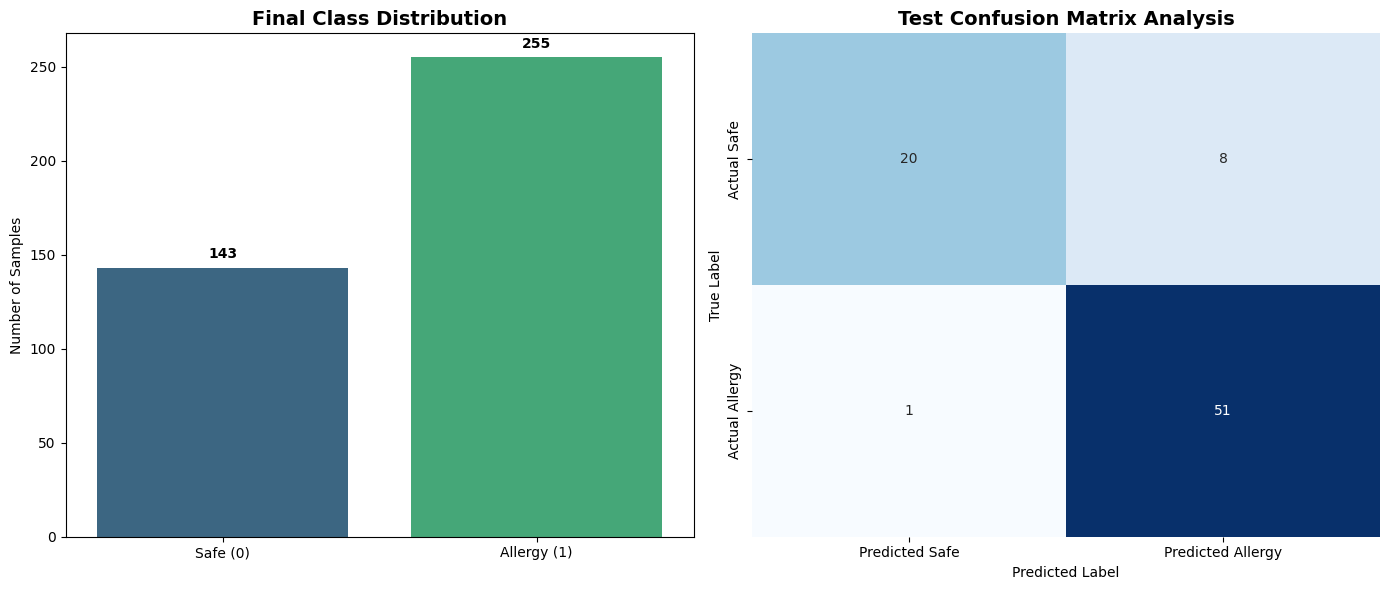

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data from your final performance results
# TP=51, TN=20, FN=1, FP=8
confusion_matrix_data = np.array([[20, 8], [1, 51]])
class_counts = [143, 255] # Safe vs Allergy
labels = ['Safe (0)', 'Allergy (1)']

# Set up the figure
plt.figure(figsize=(14, 6))

# Plot 1: Class Distribution
plt.subplot(1, 2, 1)
sns.barplot(x=labels, y=class_counts, palette='viridis')
plt.title('Final Class Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Number of Samples')
for i, v in enumerate(class_counts):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

# Plot 2: Confusion Matrix (Testing Set)
plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix_data, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Safe', 'Predicted Allergy'],
            yticklabels=['Actual Safe', 'Actual Allergy'])
plt.title('Test Confusion Matrix Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()
